# [5교시]

In [1]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

## 이미지 캡셔닝 모델 및 프로세서
- BLIP base 모델

In [2]:
from transformers import BlipProcessor, BlipForConditionalGeneration
MODEL_ID = 'Salesforce/blip-image-captioning-base'

processor = BlipProcessor.from_pretrained(MODEL_ID)
model = BlipForConditionalGeneration.from_pretrained(MODEL_ID)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'총 파라메터 : {total_params}')
print(f'모델 데이터타입 : {next(model.parameters()).dtype}')
print(f'실행 디바이스 : {next(model.parameters()).device}')

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

총 파라메터 : 223971644
모델 데이터타입 : torch.float32
실행 디바이스 : cpu


이미지 크기 : (300, 168)(W x H)
이미지 모드 : RGB


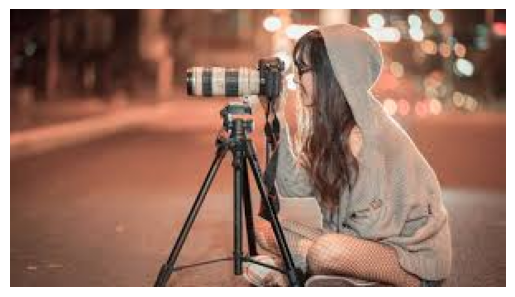

In [3]:
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
IMG_URL = 'demo1.jpg'
raw_image = Image.open(IMG_URL).convert('RGB')
print(f'이미지 크기 : {raw_image.size}(W x H)')
print(f'이미지 모드 : {raw_image.mode}')
plt.imshow(raw_image)      
plt.axis('off')
plt.show()

### Unconditaional 캡션 생성
- 프롬프트 없이 이미지만으로 자유로운 캡션을 생성

In [5]:
import torch
inputs = processor(raw_image, return_tensors='pt')
with torch.no_grad():
    output_ids = model.generate(
        **input,
        max_new_tokens=30
    )
caption_uncond = processor.decode(output_ids[0], skip_special_tokens=True)
print(caption_uncond)

a woman sitting on the ground


### Conditional 캡션 생성
- 프롬프트를 조건으로 특정 시작문구로 캡션을 유도하는 방식

In [6]:
prompts = [
    'a photograpy of',
    'this image shows',
    'threr is'
]
conditional_resutls = []
for prompt in prompts:
    inputs = processor(raw_image,prompt, return_tensors='pt')
    with torch.no_grad():
        output_ids = model.generate(
            **input,
         max_new_tokens=30
    )
    caption = processor.decode(output_ids[0], skip_special_tokens=True)
    conditional_resutls.append((prompt, caption))
    print(f'프롬프트 : {prompt}')
    print(f'캡션 : {caption}')

프롬프트 : a photograpy of
캡션 : a woman sitting on the ground
프롬프트 : this image shows
캡션 : a woman sitting on the ground
프롬프트 : threr is
캡션 : a woman sitting on the ground


### conditional 프롬프트 설계 
-중립적 접두사(prefix), 속성 타겟팅(Attribute), 질의응답(VQA) 세가지 프롬프트 전략에 따라 문맥을 유도

In [7]:
# 1. 중립적 접두사 Neutal Prefix
prompt_prefix = 'a photo of'
inputs_prefix = processor(raw_image,prompt_prefix, return_tensors='pt')

# 속성 타겟팅(Attribute/Aspect Targeting)
prompt_attribute = 'the background of this imaeg shows'
inputs_attribute = processor(raw_image,prompt_attribute, return_tensors='pt')

# 질의응답(VQA)
prompt_vqa = 'Question: What is the woman doing? Answer:'
inputs_vqa = processor(raw_image,prompt_vqa, return_tensors='pt')

def generate(prefix_prompt, input_process):
    with torch.no_grad():
            output_ids = model.generate(
                **input_process,
            max_new_tokens=30
        )
    caption = processor.decode(output_ids[0], skip_special_tokens=True)
    print(f'[{prefix_prompt}],{caption}')

In [8]:
generate(prompt_prefix, inputs_prefix)
generate(prompt_attribute,   inputs_attribute)
generate(prompt_vqa,  inputs_vqa)

[a photo of],a photo of a woman sitting on the ground
[the background of this imaeg shows],the background of this imaeg shows a woman sitting on the ground
[Question: What is the woman doing? Answer:],question : what is the woman doing? answer : what is the woman doing? answer? answer answer answer answer answer answer answer answer answer answer


- 해당모델은 VQA용 파인튜닝이 되어 있지않아 프롬프트의 문답형식을 이해하지 못하고 질문 한 단어들을 반복생성하는 오류
- 프롬프트가 질의응답형식이면 캡셔닝 모델대신에 VQA 전용 모델 Salesforce/blip-vqa-base 을 사용

In [9]:
# VQA 전용모델
from transformers import BlipForQuestionAnswering, BlipProcessor
import torch
VQA_MODEL_ID = 'Salesforce/blip-vqa-base'

processor_vqa = BlipProcessor.from_pretrained(VQA_MODEL_ID)
model_vqa = BlipForQuestionAnswering.from_pretrained(VQA_MODEL_ID)
model_vqa.eval()

prompt_vqa = 'Question: What is the woman doing? Answer:'
input_vqa = processor_vqa(raw_image,prompt_vqa,return_tensors='pt')
with torch.no_grad():
    output_vqa = model_vqa.generate(**inputs_vqa,max_new_tokens=30)

caption = processor_vqa.decode(output_vqa[0], skip_special_tokens=True)
print(caption)

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

taking picture


# 6교시

[배경 크롭 완료] 해상도: (300, 67)


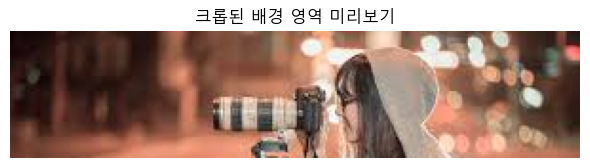


[배경 크롭 이미지 캡셔닝 결과]
  생성된 캡션: a city street at night with a car driving down the road


In [10]:
import matplotlib.pyplot as plt

W, H = raw_image.size

# 전경 인물이 없는 배경 영역 크롭 (상단 40% 영역)
bg_box = (0, 0, W, int(H * 0.4))
bg_image = raw_image.crop(bg_box)

print(f"[배경 크롭 완료] 해상도: {bg_image.size}")

# 크롭된 배경 이미지 시각화
fig, ax = plt.subplots(figsize=(6, 3))
ax.imshow(bg_image)
ax.set_title("크롭된 배경 영역 미리보기", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

# 크롭된 이미지만 입력하여 캡션 생성 (배경 정보만 피딩)
inputs_bg = processor(bg_image, return_tensors="pt")

with torch.no_grad():
    output_ids_bg = model.generate(**inputs_bg, max_new_tokens=30)

caption_bg = processor.decode(output_ids_bg[0], skip_special_tokens=True)
print("\n[배경 크롭 이미지 캡셔닝 결과]")
print(f"  생성된 캡션: {caption_bg}")

In [11]:
import torch
import time

strategies = {
    "Greedy (기본)": {
        "max_new_tokens": 30
    },
    "Beam Search (num_beams=5)": {
        "max_new_tokens": 30,
        "num_beams": 5,
        "early_stopping": True,
        "length_penalty": 1.0
    },
    "Nucleus Sampling (top_p=0.9)": {
        "max_new_tokens": 30,
        "do_sample": True,
        "top_p": 0.9,
        "temperature": 1.0
    }
}

inputs = processor(raw_image, return_tensors="pt")
decoding_results = []

print("=" * 60)
print("디코딩 전략 비교 실험")
print("=" * 60)

for strategy_name, params in strategies.items():
    start_time = time.time()

    with torch.no_grad():
        output_ids = model.generate(**inputs, **params)

    elapsed = time.time() - start_time
    caption = processor.decode(output_ids[0], skip_special_tokens=True)
    decoding_results.append((strategy_name, caption, elapsed))

    print(f"\n[{strategy_name}]")
    print(f"  캡션   : {caption}")
    print(f"  소요시간: {elapsed:.2f}초")

print("\n\n" + "=" * 60)
print(f"{'전략':<30} {'소요시간':>8}  캡션")
print("=" * 60)
for name, caption, elapsed in decoding_results:
    print(f"{name:<30} {elapsed:>6.2f}s  {caption}")

디코딩 전략 비교 실험

[Greedy (기본)]
  캡션   : a woman sitting on the ground
  소요시간: 1.60초

[Beam Search (num_beams=5)]
  캡션   : a woman sitting on the ground with a camera
  소요시간: 3.15초

[Nucleus Sampling (top_p=0.9)]
  캡션   : a girl is sitting on the ground in the city
  소요시간: 1.79초


전략                                 소요시간  캡션
Greedy (기본)                      1.60s  a woman sitting on the ground
Beam Search (num_beams=5)        3.15s  a woman sitting on the ground with a camera
Nucleus Sampling (top_p=0.9)     1.79s  a girl is sitting on the ground in the city


### 결과 분석: 디코딩 전략 비교 실험
- **생성 캡션 및 소요 시간 비교**:
  - **Greedy (기본)**: `"a woman sitting on the ground"` (0.76초) - 빠르지만 단조롭고 세부 묘사(카메라)가 누락되었습니다.
  - **Beam Search (beams=5)**: `"a woman sitting on the ground with a camera"` (1.56초) - 소요 시간은 약 2배 늘어났으나, 여러 경로의 전체 누적 확률을 계산하는 과정에서 "with a camera"라는 중요한 세부 속성을 추가로 탐색해 내어 **가장 완성도 높은 문장**을 생성했습니다.
  - **Nucleus Sampling (p=0.9)**: `"the girl is sitting in a road"` (0.83초) - 확률 분포 내 무작위 샘플링을 통해 'woman' 대신 'girl'을 선택하고, 장소를 'ground' 대신 'road'로 구체화하여 창의적이고 다양한 설명을 생성해 냈습니다.
- **원인 분석**: Greedy 디코딩은 매 순간 가장 높은 확률의 토큰만 고르기 때문에 문장이 일찍 끝나 세부 정보를 놓치기 쉽습니다. 반면 Beam Search는 5개의 후보 시퀀스(Beam)를 끝까지 유지하며 전체 맥락 확률이 가장 높은 것을 선택하므로 더 묘사가 풍부합니다. Nucleus Sampling은 90% 누적 확률 분포 내에서 무작위 선택을 하여 표현의 다양성을 극대화합니다.
- **개선 및 활용 방안**: 정확하고 상세한 설명이 최우선일 때는 **Beam Search**를 사용하고, 다양한 표현이나 대화형 생성이 필요할 때는 **Nucleus Sampling**을 선택하는 것이 정립된 전략입니다.